<a href="https://colab.research.google.com/github/gunasekaran01/apexplanet_task4/blob/main/apexplanet_task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install openpyxl scipy seaborn

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

# Display plots inside notebook
%matplotlib inline

# Chart style
plt.style.use("ggplot")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving EDA_Cleaned_Dataset.csv to EDA_Cleaned_Dataset.csv


In [ ]:
df = pd.read_csv("EDA_Cleaned_Dataset.csv")

In [ ]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Month,Year
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,February,2025
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,October,2025
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,May,2025
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,December,2025
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,November,2025


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 14


In [ ]:
df.info()
print(df.isnull().sum())
print("Duplicate Rows :", df.duplicated().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            1000 non-null   float64
 5   Gender         1000 non-null   object 
 6   City           1000 non-null   object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
 12  Month          1000 non-null   object 
 13  Year           1000 non-null   int64  
dtypes: float64(3), int64(2), object(9)
memory usage: 109.5+ KB
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City        

,Age,Quantity,Unit_Price,Total_Sales,Year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650,2025.005000
std,13.683626,2.838632,14179.402361,114100.051546,0.070569
min,18.000000,1.000000,145.780000,437.340000,2025.000000
25%,30.000000,3.000000,13895.722500,47066.632500,2025.000000
50%,41.000000,5.000000,25398.740000,108594.025000,2025.000000
75%,53.000000,8.000000,37512.382500,203722.882500,2025.000000
max,65.000000,10.000000,49997.530000,493677.500000,2026.000000


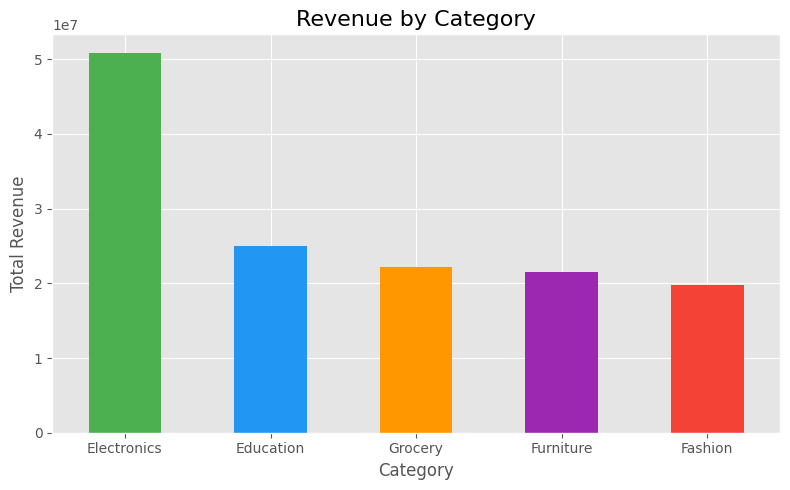

In [ ]:
# Revenue by Category

category_sales = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar",
    color=["#4CAF50","#2196F3","#FF9800","#9C27B0","#F44336"]
)

plt.title("Revenue by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("Revenue_by_Category.png", dpi=300)

plt.show()

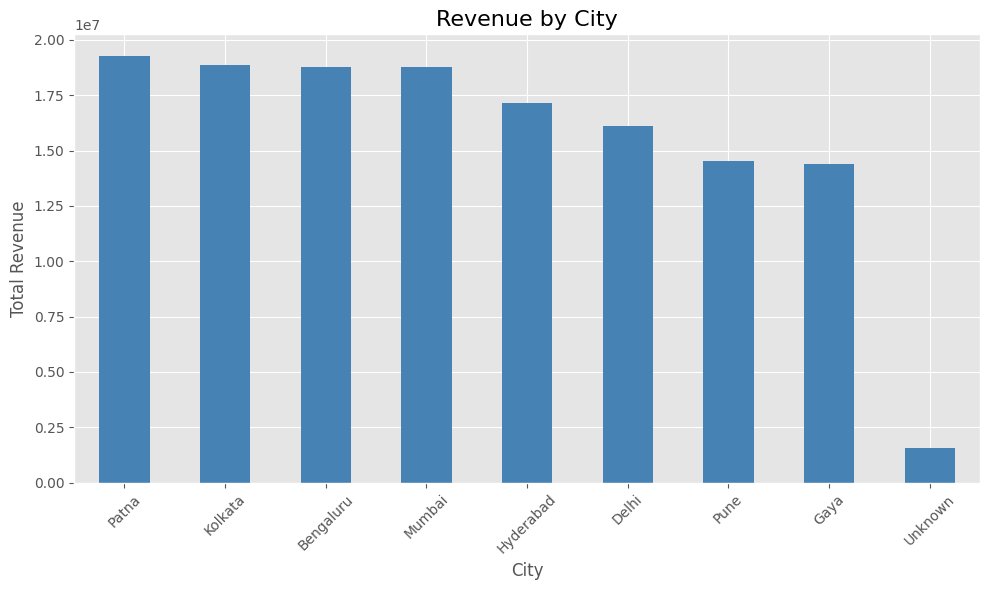

In [ ]:
city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

city_sales.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Revenue by City", fontsize=16)
plt.xlabel("City")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("Revenue_by_City.png", dpi=300)

plt.show()

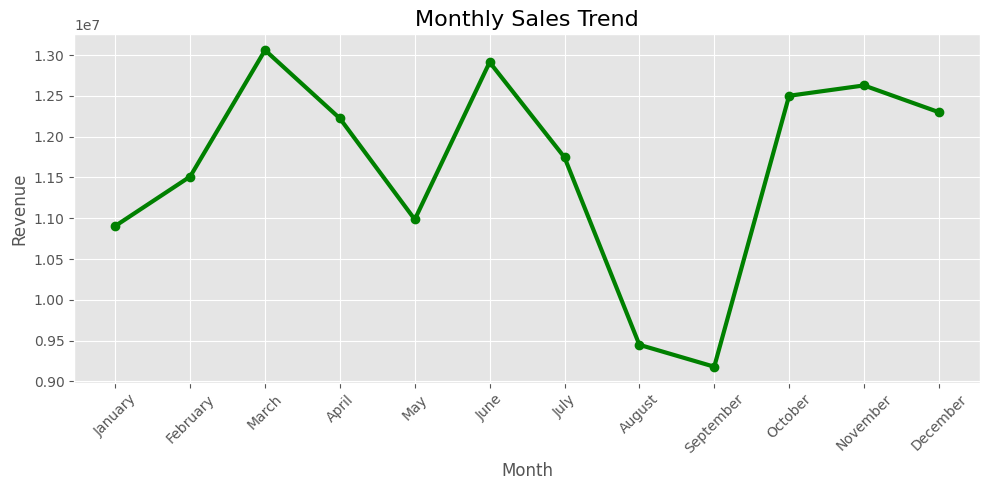

In [ ]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("Month")["Total_Sales"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=3,
    color="green"
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig("Monthly_Sales_Trend.png", dpi=300)

plt.show()

/tmp/ipykernel_593/2769225142.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


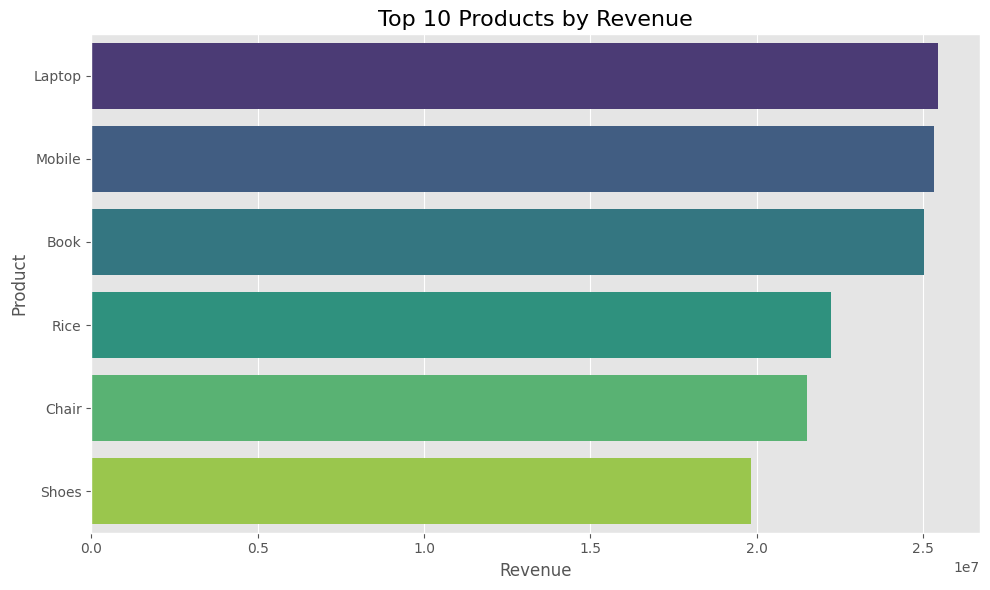

In [ ]:
top_products = (
    df.groupby("Product")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="viridis"
)

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("Top10_Products.png", dpi=300)

plt.show()

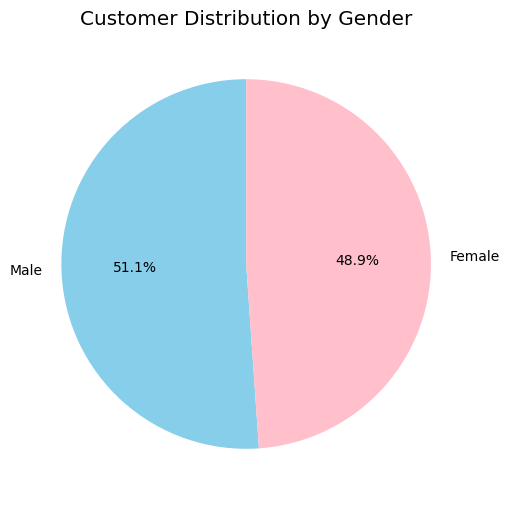

In [ ]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue","pink"]
)

plt.title("Customer Distribution by Gender")

plt.savefig("Gender_Distribution.png", dpi=300)

plt.show()

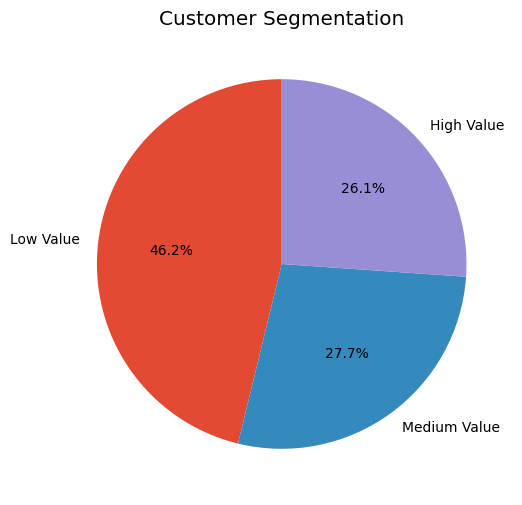

In [ ]:
df["Customer Segment"] = pd.cut(
    df["Total_Sales"],
    bins=[0,100000,200000,float("inf")],
    labels=["Low Value","Medium Value","High Value"]
)
segment = df["Customer Segment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    segment,
    labels=segment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segmentation")

plt.savefig("Customer_Segmentation.png", dpi=300)

plt.show()

             Quantity  Unit_Price  Total_Sales
Quantity     1.000000    0.021855     0.646641
Unit_Price   0.021855    1.000000     0.686303
Total_Sales  0.646641    0.686303     1.000000


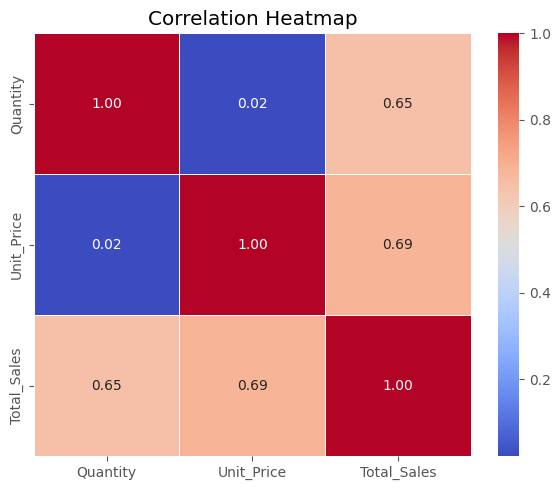

In [ ]:
# Select numerical columns
numeric_df = df[["Quantity", "Unit_Price", "Total_Sales"]]

# Correlation Matrix
corr = numeric_df.corr()

print(corr)
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("Correlation_Heatmap.png", dpi=300)

plt.show()

In [ ]:
male_sales = df[df["Gender"] == "Male"]["Total_Sales"]

female_sales = df[df["Gender"] == "Female"]["Total_Sales"]

t_stat, p_value = ttest_ind(male_sales, female_sales)

print("T-Statistic :", round(t_stat,4))
print("P-Value :", round(p_value,4))
alpha = 0.05

if p_value < alpha:
    print("Decision : Reject the Null Hypothesis")
    print("Conclusion : There is a statistically significant difference in average sales between male and female customers.")
else:
    print("Decision : Fail to Reject the Null Hypothesis")
    print("Conclusion : There is no statistically significant difference in average sales between male and female customers.")

T-Statistic : 0.682
P-Value : 0.4954
Decision : Fail to Reject the Null Hypothesis
Conclusion : There is no statistically significant difference in average sales between male and female customers.


/tmp/ipykernel_593/1570304100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


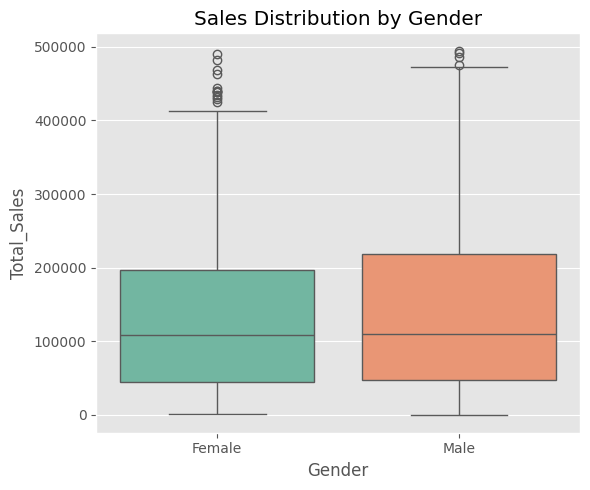

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Total_Sales",
    palette="Set2"
)

plt.title("Sales Distribution by Gender")

plt.tight_layout()

plt.savefig("Gender_vs_Sales.png", dpi=300)

plt.show()

In [ ]:
contingency_table = pd.crosstab(
    df["Gender"],
    df["Category"]
)

print(contingency_table)
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", round(chi2,4))
print("P-Value :", round(p,4))
print("Degrees of Freedom :", dof)
if p < 0.05:
    print("Decision : Reject the Null Hypothesis")
    print("Conclusion : Gender and Product Category are statistically associated.")
else:
    print("Decision : Fail to Reject the Null Hypothesis")
    print("Conclusion : No statistically significant association exists between Gender and Product Category.")

Category  Education  Electronics  Fashion  Furniture  Grocery
Gender                                                       
Female           96          158       89         74       72
Male             82          196       67         85       81
Chi-Square Statistic : 9.0936
P-Value : 0.0588
Degrees of Freedom : 4
Decision : Fail to Reject the Null Hypothesis
Conclusion : No statistically significant association exists between Gender and Product Category.


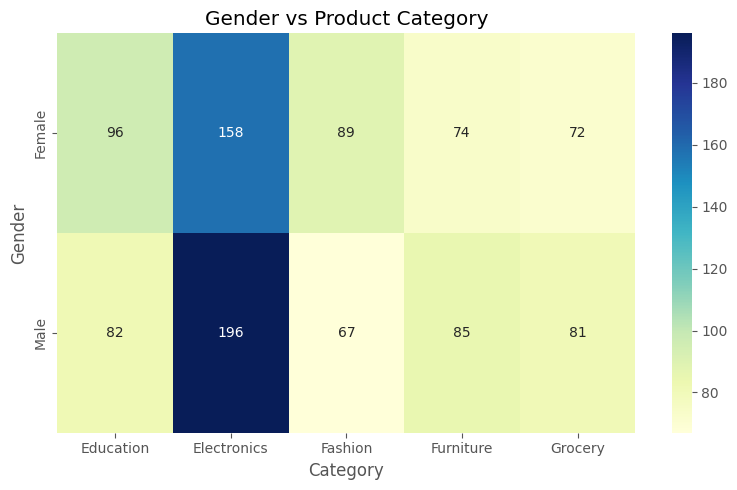

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    contingency_table,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Gender vs Product Category")

plt.tight_layout()

plt.savefig("Gender_Category_Heatmap.png", dpi=300)

plt.show()